In [1]:
import os
foldername = '/home/edavenport/analysis/vel-assim-manuscript/forecasts/results_figs/skill/multi_window/'
os.makedirs(foldername, exist_ok=True)

# ── Climatology baseline mode ─────────────────────────────────────────────────
# 'sigma_clim' : RMS of the monthly-std profile (historical variability)
# 'rmse_clim'  : RMSE of the monthly-mean profile vs actual forecast obs
# 'both'       : generate figures for both modes
clim_mode = 'both'

## Configuration
Edit this cell to add windows as runs complete. All other cells run without modification.

In [2]:
import sys
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))
import pandas as pd
import numpy as np
from forecasts.forecast_utils import get_forecast_params, load_hycom_daily

# ── All 4-month forecast windows ─────────────────────────────────────────────
ALL_WINDOWS = [
    pd.Timestamp('2012-09-01'),
    pd.Timestamp('2012-11-01'),
    pd.Timestamp('2013-01-01'),
    pd.Timestamp('2013-03-01'),
    pd.Timestamp('2013-05-01'),
    pd.Timestamp('2013-07-01'),
]

# ── TPOSE-Vel State Estimate: manual dirs (naming convention varies by run) ───
# Set None for windows not yet available; windows without vel estimate omitted.
VEL_EST_DIRS = {
    pd.Timestamp('2012-09-01'): '/data/SO3/edavenport/tpose6/sep2012/velocity_assim_0825/run_iter22',
    pd.Timestamp('2012-11-01'): '/data/SO3/edavenport/tpose6/nov2012/run_iter20',
    pd.Timestamp('2013-01-01'): '/data/SO3/edavenport/tpose6/jan2013/run_iter14',
    pd.Timestamp('2013-03-01'): '/data/SO3/edavenport/tpose6/mar2013/run_iter16',
}

# ── Vel estimate itPerFile override ──────────────────────────────────────────
# Only needed when vel estimate timestep differs from noVel estimate for that window.
# sep2012: noVel uses 48 iters/day (1800s), but run_iter24 uses 72 iters/day (1200s).
VEL_EST_ITERS_PER_FILE = {
    pd.Timestamp('2012-09-01'): 72,
}

# ── GLORYS: single location for all windows ───────────────────────────────────
GLORYS_PATH = '/data/SO3/edavenport/tpose6/glorys_data/glorys_*.nc'

# ── TAO ADCP files (try both years; concatenate if both exist) ────────────────
TAO_ADCP_FILES = [
    '/data/SO3/edavenport/tpose6/tao_profiles/TAO_WO_2012_ADCP_v2.nc',
    '/data/SO3/edavenport/tpose6/tao_profiles/TAO_WO_2013_ADCP.nc',
]

# ── TAO mooring locations and climatology ────────────────────────────────────
TAO_LONS       = np.array([190., 220., 250.])   # degrees E (0:360 convention)
TAO_LOC_LABELS = ['170W', '140W', '110W']
TAO_CLIM_DIR   = 'forecasts/tao_data/'   # relative to cwd (forecasts/)

In [3]:
import matplotlib.pyplot as plt
import xarray as xr
from xmitgcm import open_mdsdataset
plt.rcParams['font.size'] = 14

# ── Load TAO ADCP (all available years, concatenated) ─────────────────────────
adcp_parts = [xr.open_dataset(f) for f in TAO_ADCP_FILES if os.path.exists(f)]
if not adcp_parts:
    raise FileNotFoundError('No TAO ADCP files found.')

# Extract depths from first file before concat; concat promotes prof_depth to 2D
tao_adcp_depths = adcp_parts[0].prof_depth.values   # (iDEPTH,) positive downward

adcp = xr.concat(adcp_parts, dim='iPROF') if len(adcp_parts) > 1 else adcp_parts[0]

tao_raw_dates = pd.to_datetime(
    adcp.prof_YYYYMMDD.values.astype(int).astype(str), format='%Y%m%d')
tao_u_raw = adcp.prof_U.values.copy().astype(float)
tao_v_raw = adcp.prof_V.values.copy().astype(float)
tao_u_raw[tao_u_raw == -9999.] = np.nan
tao_v_raw[tao_v_raw == -9999.] = np.nan
tao_adcp_lons = adcp.prof_lon.values

print(f'TAO ADCP loaded: {len(tao_raw_dates)} profiles, depth range {tao_adcp_depths[0]}–{tao_adcp_depths[-1]} m')
print(f'Date range: {tao_raw_dates.min().date()} -> {tao_raw_dates.max().date()}')

# ── Load GLORYS velocity (full time span; sliced per window in loop) ───────────
glorys = xr.open_mfdataset(GLORYS_PATH, combine='by_coords')

print('GLORYS loaded.')

/tmp/ipykernel_137369/1820328341.py:14: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  adcp = xr.concat(adcp_parts, dim='iPROF') if len(adcp_parts) > 1 else adcp_parts[0]


TAO ADCP loaded: 70360 profiles, depth range 10.0–315.0 m
Date range: 2011-12-31 -> 2013-12-31
GLORYS loaded.


In [4]:
# ── Load TAO climatology (independent of windows) ────────────────────────────
adcp_depth_da = xr.DataArray(tao_adcp_depths, dims='depth')

n_loc = len(TAO_LONS)
clim_u_mean = np.full((n_loc, 12, len(tao_adcp_depths)), np.nan)
clim_v_mean = np.full((n_loc, 12, len(tao_adcp_depths)), np.nan)
clim_u_std  = np.full((n_loc, 12, len(tao_adcp_depths)), np.nan)
clim_v_std  = np.full((n_loc, 12, len(tao_adcp_depths)), np.nan)

for j, loc_label in enumerate(TAO_LOC_LABELS):
    ds_c = xr.open_dataset(f'{TAO_CLIM_DIR}tao_clim_{loc_label}_1993to2012.nc')
    clim_u_mean[j] = ds_c.u_mean.interp(depth=adcp_depth_da, method='linear').values
    clim_v_mean[j] = ds_c.v_mean.interp(depth=adcp_depth_da, method='linear').values
    clim_u_std[j]  = ds_c.u_std.interp(depth=adcp_depth_da,  method='linear').values
    clim_v_std[j]  = ds_c.v_std.interp(depth=adcp_depth_da,  method='linear').values

print('TAO climatology loaded for all locations.')

TAO climatology loaded for all locations.


In [5]:
# ── Per-window RMSE loop ──────────────────────────────────────────────────────

import copy
prefix = ['diag_state']

PRODUCT_KEYS = [
    'noVel_est_u', 'noVel_est_v',
    'noVel_fct_u', 'noVel_fct_v',
    'noVel_pers_u', 'noVel_pers_v',
    'vel_est_u',   'vel_est_v',
    'vel_fct_u',   'vel_fct_v',
    'vel_pers_u',  'vel_pers_v',
    'glorys_u',    'glorys_v',
    'hycom_u',     'hycom_v',
    'rmse_clim_u', 'rmse_clim_v',
    'sigma_clim_u', 'sigma_clim_v',
]
rmse_lists = {k: [] for k in PRODUCT_KEYS}
n_wins     = {k: 0  for k in PRODUCT_KEYS}
max_days   = 0


def open_tpose_win(data_dir, p):
    ds = open_mdsdataset(
        data_dir=data_dir, grid_dir=p.grid_dir,
        iters=p.intervals, prefix=prefix,
        ref_date=p.ref_date, delta_t=p.delta_t)
    for coord in ['XC', 'YC', 'Z', 'XG', 'YG']:
        ds[coord] = ds[coord].astype(float)
    return ds


def vel_est_params(win_start, p):
    """Return params with itPerFile/intervals overridden for the vel estimate if needed."""
    ipf = VEL_EST_ITERS_PER_FILE.get(win_start)
    if ipf is None or ipf == p.itPerFile:
        return p
    p2 = copy.copy(p)
    p2.itPerFile = ipf
    p2.delta_t   = 1440 / ipf * 60
    p2.intervals = range(ipf, ipf * (p.n_forecast_days + 1), ipf)
    return p2


def per_loc_rmse(model, obs):
    """RMS over valid depths at each (time, location). Inputs: (time, loc, depth)."""
    diff    = model - obs
    n_valid = np.sum(np.isfinite(diff), axis=2)
    return np.sqrt(np.nansum(diff**2, axis=2) / np.maximum(n_valid, 1))


def extract_tpose_vel(ds, p, tpose_eval_slice):
    """Interpolate TPOSE UVEL/VVEL to TAO locations and depths. Returns (u, v) numpy arrays."""
    ds_eval   = ds.isel(time=tpose_eval_slice)
    loc_da    = xr.DataArray(TAO_LONS,               dims='location')
    depth_da  = xr.DataArray(-tao_adcp_depths,       dims='depth')

    u = (ds_eval.UVEL
           .sel(YC=0.0, method='nearest')
           .interp(XG=loc_da, Z=depth_da, method='linear')
           .transpose('time', 'location', 'depth')
           .compute()).values
    v = (ds_eval.VVEL
           .sel(YG=0.0, method='nearest')
           .interp(XC=loc_da, Z=depth_da, method='linear')
           .transpose('time', 'location', 'depth')
           .compute()).values
    return u, v


for win_start in ALL_WINDOWS:
    p       = get_forecast_params(win_start)
    win_end = p.end_date
    wlabel  = f"{p.month_str}{p.year_str}"
    n_days  = p.n_forecast_days
    print(f'\n=== {win_start.date()} -> {win_end.date()} ({n_days} days) ===')

    eval_dates_win = pd.date_range(win_start, periods=n_days)
    max_days = max(max_days, n_days)

    # ── TAO obs for this window ───────────────────────────────────
    tao_u_win = np.full((n_days, n_loc, len(tao_adcp_depths)), np.nan)
    tao_v_win = np.full((n_days, n_loc, len(tao_adcp_depths)), np.nan)
    for i, d in enumerate(eval_dates_win):
        for j, lon in enumerate(TAO_LONS):
            mask = (tao_raw_dates == d) & (tao_adcp_lons == lon)
            if mask.sum() > 0:
                tao_u_win[i, j, :] = np.nanmean(tao_u_raw[mask, :], axis=0)
                tao_v_win[i, j, :] = np.nanmean(tao_v_raw[mask, :], axis=0)

    has_tao = np.any(np.isfinite(tao_u_win))
    if not has_tao:
        print(f'  WARNING: no TAO obs for {wlabel}; skipping window.')
        continue

    # ── Climatology baselines for this window ─────────────────────
    clim_fct_u  = np.full_like(tao_u_win, np.nan)
    clim_fct_v  = np.full_like(tao_v_win, np.nan)
    sig_clim_u  = np.full((n_days, n_loc), np.nan)
    sig_clim_v  = np.full((n_days, n_loc), np.nan)
    for t, d in enumerate(eval_dates_win):
        m = d.month - 1
        clim_fct_u[t] = clim_u_mean[:, m, :]
        clim_fct_v[t] = clim_v_mean[:, m, :]
        for j in range(n_loc):
            su = clim_u_std[j, m, :]; valid = np.isfinite(su)
            if valid.sum() > 0:
                sig_clim_u[t, j] = np.sqrt(np.mean(su[valid]**2))
            sv = clim_v_std[j, m, :]; valid = np.isfinite(sv)
            if valid.sum() > 0:
                sig_clim_v[t, j] = np.sqrt(np.mean(sv[valid]**2))

    rc_u = per_loc_rmse(clim_fct_u, tao_u_win)
    rc_v = per_loc_rmse(clim_fct_v, tao_v_win)
    rmse_lists['rmse_clim_u'].append(rc_u);     n_wins['rmse_clim_u'] += 1
    rmse_lists['rmse_clim_v'].append(rc_v);     n_wins['rmse_clim_v'] += 1
    rmse_lists['sigma_clim_u'].append(sig_clim_u); n_wins['sigma_clim_u'] += 1
    rmse_lists['sigma_clim_v'].append(sig_clim_v); n_wins['sigma_clim_v'] += 1

    # ── resolve directories ───────────────────────────────────────
    # vel_est_dir may be None; when absent, noVel_est/GLORYS/HYCOM are excluded
    # but forecasts are still included if their directories exist.
    vel_est_dir   = VEL_EST_DIRS.get(win_start)
    novel_est_dir = p.noTAO_data_dir          if os.path.isdir(p.noTAO_data_dir)          else None
    vel_fct_dir   = p.vel_forecast_data_dir   if os.path.isdir(p.vel_forecast_data_dir)   else None
    novel_fct_dir = p.noTAO_forecast_data_dir if os.path.isdir(p.noTAO_forecast_data_dir) else None

    for name, d in [('noVel est', novel_est_dir), ('noVel fct', novel_fct_dir),
                    ('vel est',   vel_est_dir),   ('vel fct',   vel_fct_dir)]:
        print(f'  {name:10s}: {d or "MISSING"}')

    # ── TPOSE datasets ────────────────────────────────────────────
    p_vel        = vel_est_params(win_start, p)
    ds_novel_est = open_tpose_win(novel_est_dir,  p)     if novel_est_dir  else None
    ds_novel_fct = open_tpose_win(novel_fct_dir,  p)     if novel_fct_dir  else None
    ds_vel_est   = open_tpose_win(vel_est_dir,    p_vel) if vel_est_dir    else None
    ds_vel_fct   = open_tpose_win(vel_fct_dir,    p)     if vel_fct_dir    else None

    def add_tpose(ds, key_u, key_v):
        if ds is None:
            return
        u, v = extract_tpose_vel(ds, p, p.eval_slice)
        rmse_lists[key_u].append(per_loc_rmse(u, tao_u_win)); n_wins[key_u] += 1
        rmse_lists[key_v].append(per_loc_rmse(v, tao_v_win)); n_wins[key_v] += 1

    def add_persistence(ds, key_u, key_v):
        if ds is None:
            return
        u, v = extract_tpose_vel(ds, p, p.eval_slice)
        rmse_lists[key_u].append(per_loc_rmse(np.broadcast_to(u[0:1], u.shape), tao_u_win)); n_wins[key_u] += 1
        rmse_lists[key_v].append(per_loc_rmse(np.broadcast_to(v[0:1], v.shape), tao_v_win)); n_wins[key_v] += 1

    # Forecasts: always included when data exists
    add_tpose(ds_novel_fct, 'noVel_fct_u', 'noVel_fct_v')
    add_tpose(ds_vel_est,   'vel_est_u',   'vel_est_v')
    add_tpose(ds_vel_fct,   'vel_fct_u',   'vel_fct_v')
    add_persistence(ds_novel_fct, 'noVel_pers_u', 'noVel_pers_v')
    add_persistence(ds_vel_fct,   'vel_pers_u',   'vel_pers_v')

    # State estimates and reanalysis: only when vel estimate exists for this window
    if vel_est_dir is not None:
        add_tpose(ds_novel_est, 'noVel_est_u', 'noVel_est_v')

        glorys_wind = glorys[['uo', 'vo']].sel(
            time=slice(win_start.strftime('%Y-%m-%d'), win_end.strftime('%Y-%m-%d')),
            latitude=slice(-5, 5)
        )
        tao_lons_neg = TAO_LONS - 360
        loc_da_g   = xr.DataArray(tao_lons_neg,    dims='location')
        depth_da_g = xr.DataArray(tao_adcp_depths, dims='depth')

        gu = (glorys_wind.uo
                .sel(latitude=0.0, method='nearest')
                .interp(longitude=loc_da_g, depth=depth_da_g, method='linear')
                .transpose('time', 'location', 'depth')
                .isel(time=p.eval_slice)
                .compute()).values
        gv = (glorys_wind.vo
                .sel(latitude=0.0, method='nearest')
                .interp(longitude=loc_da_g, depth=depth_da_g, method='linear')
                .transpose('time', 'location', 'depth')
                .isel(time=p.eval_slice)
                .compute()).values

        rmse_lists['glorys_u'].append(per_loc_rmse(gu, tao_u_win)); n_wins['glorys_u'] += 1
        rmse_lists['glorys_v'].append(per_loc_rmse(gv, tao_v_win)); n_wins['glorys_v'] += 1

        hycom = load_hycom_daily(win_start, win_end)
        if hycom is not None:
            hycom_wind = hycom[['water_u', 'water_v']].sel(lat=slice(-5, 5))
            loc_da_h   = xr.DataArray(tao_lons_neg,    dims='location')
            depth_da_h = xr.DataArray(tao_adcp_depths, dims='depth')

            hu = (hycom_wind.water_u
                    .sel(lat=0.0, method='nearest')
                    .interp(lon=loc_da_h, depth=depth_da_h, method='linear')
                    .transpose('time', 'location', 'depth')
                    .isel(time=p.eval_slice)
                    .compute()).values
            hv = (hycom_wind.water_v
                    .sel(lat=0.0, method='nearest')
                    .interp(lon=loc_da_h, depth=depth_da_h, method='linear')
                    .transpose('time', 'location', 'depth')
                    .isel(time=p.eval_slice)
                    .compute()).values

            rmse_lists['hycom_u'].append(per_loc_rmse(hu, tao_u_win)); n_wins['hycom_u'] += 1
            rmse_lists['hycom_v'].append(per_loc_rmse(hv, tao_v_win)); n_wins['hycom_v'] += 1
        else:
            print(f'  HYCOM: no data for {wlabel}')
    else:
        print(f'  vel est MISSING — noVel_est, GLORYS, HYCOM excluded for {wlabel}')

    print(f'  {wlabel} complete.')

print('\nWindows available per product (U):')
for k in ['noVel_est_u', 'noVel_fct_u', 'noVel_pers_u', 'vel_est_u', 'vel_fct_u', 'vel_pers_u', 'glorys_u', 'hycom_u']:
    print(f'  {k:15s}: {n_wins[k]}')


=== 2012-09-01 -> 2012-12-31 (121 days) ===


/tmp/ipykernel_137369/2719018897.py:88: RuntimeWarning: Mean of empty slice
  tao_u_win[i, j, :] = np.nanmean(tao_u_raw[mask, :], axis=0)
/tmp/ipykernel_137369/2719018897.py:89: RuntimeWarning: Mean of empty slice
  tao_v_win[i, j, :] = np.nanmean(tao_v_raw[mask, :], axis=0)


  noVel est : /data/SO6/TPOSE_diags/tpose6/sep2012/diags_iter7_daily/
  noVel fct : MISSING
  vel est   : /data/SO3/edavenport/tpose6/sep2012/velocity_assim_0825/run_iter22
  vel fct   : MISSING
  sep2012 complete.

=== 2012-11-01 -> 2013-02-28 (119 days) ===


/tmp/ipykernel_137369/2719018897.py:88: RuntimeWarning: Mean of empty slice
  tao_u_win[i, j, :] = np.nanmean(tao_u_raw[mask, :], axis=0)
/tmp/ipykernel_137369/2719018897.py:89: RuntimeWarning: Mean of empty slice
  tao_v_win[i, j, :] = np.nanmean(tao_v_raw[mask, :], axis=0)


  noVel est : /data/SO6/TPOSE_diags/tpose6/nov2012/diags_new/
  noVel fct : MISSING
  vel est   : /data/SO3/edavenport/tpose6/nov2012/run_iter20
  vel fct   : MISSING
  nov2012 complete.

=== 2013-01-01 -> 2013-04-30 (119 days) ===


...

  noVel est : /data/SO3/averdy/TPOSE6/mar2013/diags_daily/
  noVel fct : /data/SO3/edavenport/tpose6/forecasts/mar012013_tpose_noVel/
  vel est   : /data/SO3/edavenport/tpose6/mar2013/run_iter16
  vel fct   : /data/SO3/edavenport/tpose6/forecasts/mar012013/
  mar2013 complete.

=== 2013-05-01 -> 2013-08-31 (122 days) ===


/tmp/ipykernel_137369/2719018897.py:88: RuntimeWarning: Mean of empty slice
  tao_u_win[i, j, :] = np.nanmean(tao_u_raw[mask, :], axis=0)
/tmp/ipykernel_137369/2719018897.py:89: RuntimeWarning: Mean of empty slice
  tao_v_win[i, j, :] = np.nanmean(tao_v_raw[mask, :], axis=0)


  noVel est : /data/SO3/averdy/TPOSE6/may2013/diags_daily/
  noVel fct : /data/SO3/edavenport/tpose6/forecasts/may012013_tpose_noVel/
  vel est   : MISSING
  vel fct   : /data/SO3/edavenport/tpose6/forecasts/may012013/
  vel est MISSING — noVel_est, GLORYS, HYCOM excluded for may2013
  may2013 complete.

=== 2013-07-01 -> 2013-10-31 (122 days) ===


/tmp/ipykernel_137369/2719018897.py:88: RuntimeWarning: Mean of empty slice
  tao_u_win[i, j, :] = np.nanmean(tao_u_raw[mask, :], axis=0)
/tmp/ipykernel_137369/2719018897.py:89: RuntimeWarning: Mean of empty slice
  tao_v_win[i, j, :] = np.nanmean(tao_v_raw[mask, :], axis=0)


  noVel est : /data/SO3/averdy/TPOSE6/jul2013/diags_daily/
  noVel fct : /data/SO3/edavenport/tpose6/forecasts/jul012013_tpose_noVel/
  vel est   : MISSING
  vel fct   : /data/SO3/edavenport/tpose6/forecasts/jul012013/
  vel est MISSING — noVel_est, GLORYS, HYCOM excluded for jul2013
  jul2013 complete.

Windows available per product (U):
  noVel_est_u    : 4
  noVel_fct_u    : 4
  noVel_pers_u   : 4
  vel_est_u      : 4
  vel_fct_u      : 4
  vel_pers_u     : 4
  glorys_u       : 4
  hycom_u        : 4


In [6]:
# ── Average RMSE across windows ───────────────────────────────────────────────
# Arrays here are (n_days, n_loc), so NaN-padding is along axis 0.

def avg_over_windows_2d(arrays, max_days, n_loc):
    """NaN-pad (n_days, n_loc) arrays and nanmean across windows."""
    if not arrays:
        return None
    stacked = np.full((len(arrays), max_days, n_loc), np.nan)
    for i, arr in enumerate(arrays):
        stacked[i, :arr.shape[0], :] = arr
    return np.nanmean(stacked, axis=0)   # (max_days, n_loc)


rmse_avg = {
    k: avg_over_windows_2d(v, max_days, n_loc)
    for k, v in rmse_lists.items()
}
days_avg = np.arange(1, max_days + 1)

print(f'Averaging over max {max_days} days, {n_loc} locations.')
print('Sample noVel_est_u shape:', rmse_avg['noVel_est_u'].shape if rmse_avg['noVel_est_u'] is not None else 'N/A')

Averaging over max 122 days, 3 locations.
Sample noVel_est_u shape: (122, 3)


/tmp/ipykernel_137369/3923324956.py:11: RuntimeWarning: Mean of empty slice
  return np.nanmean(stacked, axis=0)   # (max_days, n_loc)


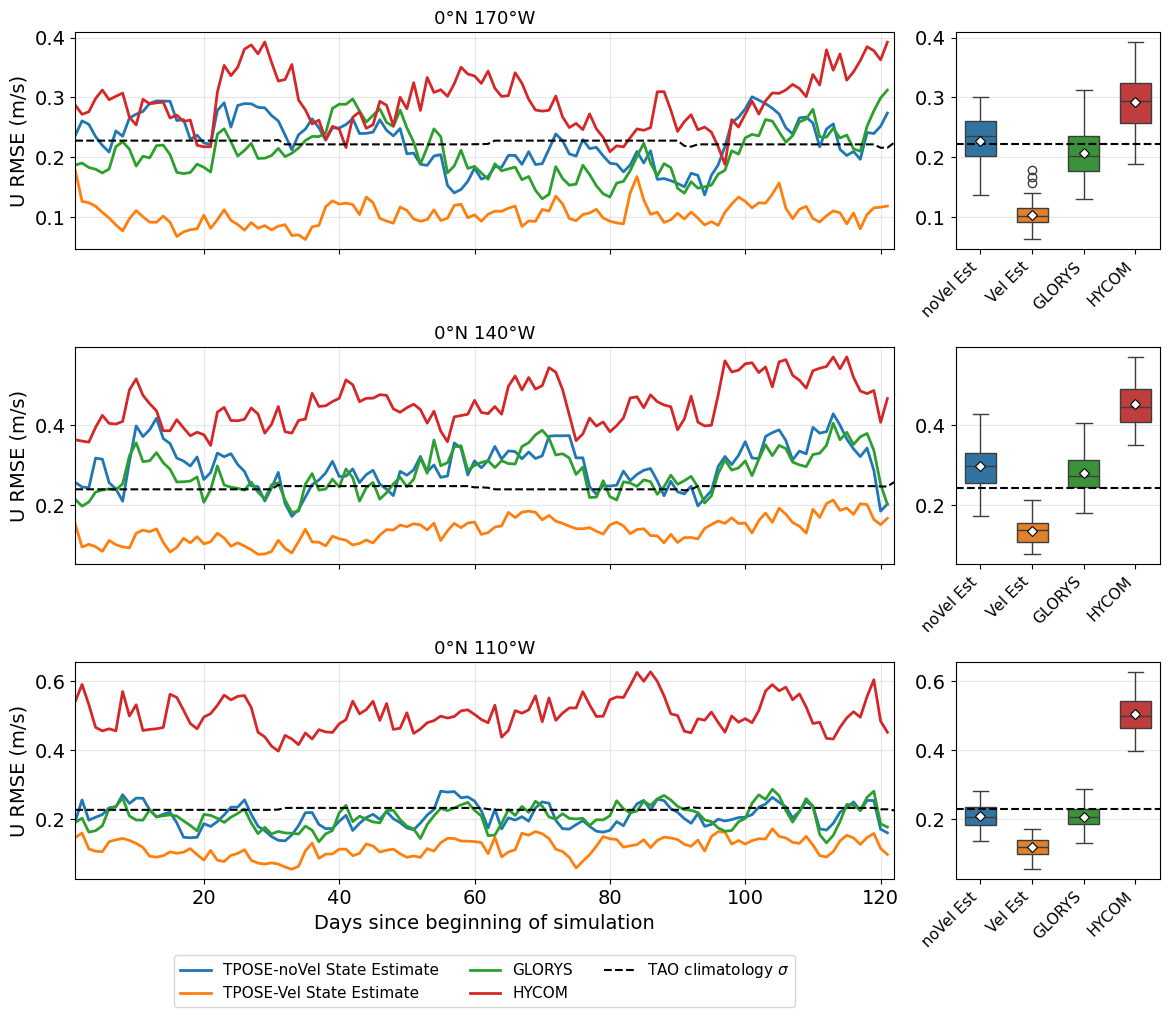

Saved /home/edavenport/analysis/vel-assim-manuscript/forecasts/results_figs/skill/multi_window/vel_u_rmse_per_loc_multi_window_sigma_clim.png


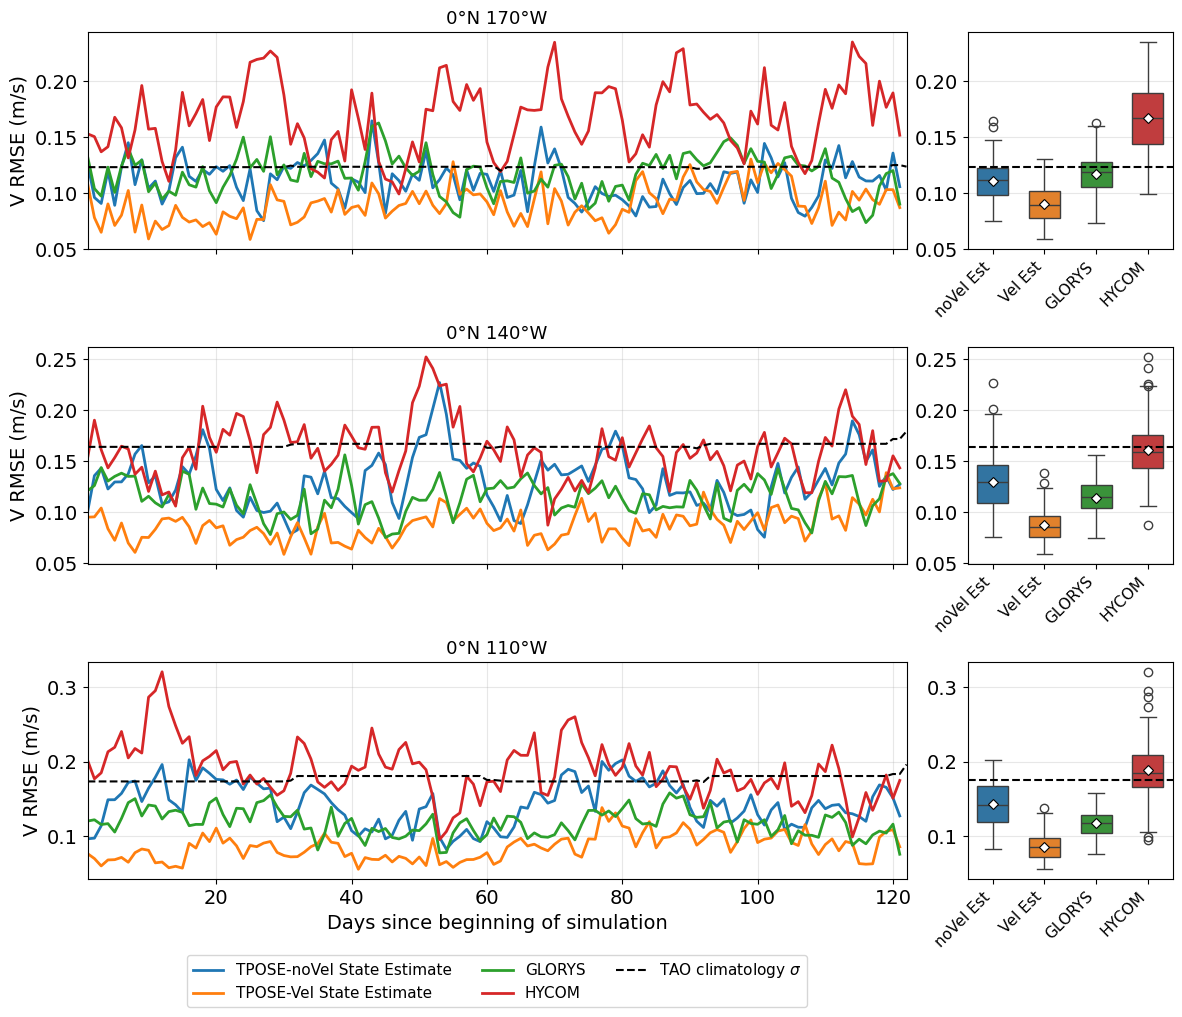

Saved /home/edavenport/analysis/vel-assim-manuscript/forecasts/results_figs/skill/multi_window/vel_v_rmse_per_loc_multi_window_sigma_clim.png


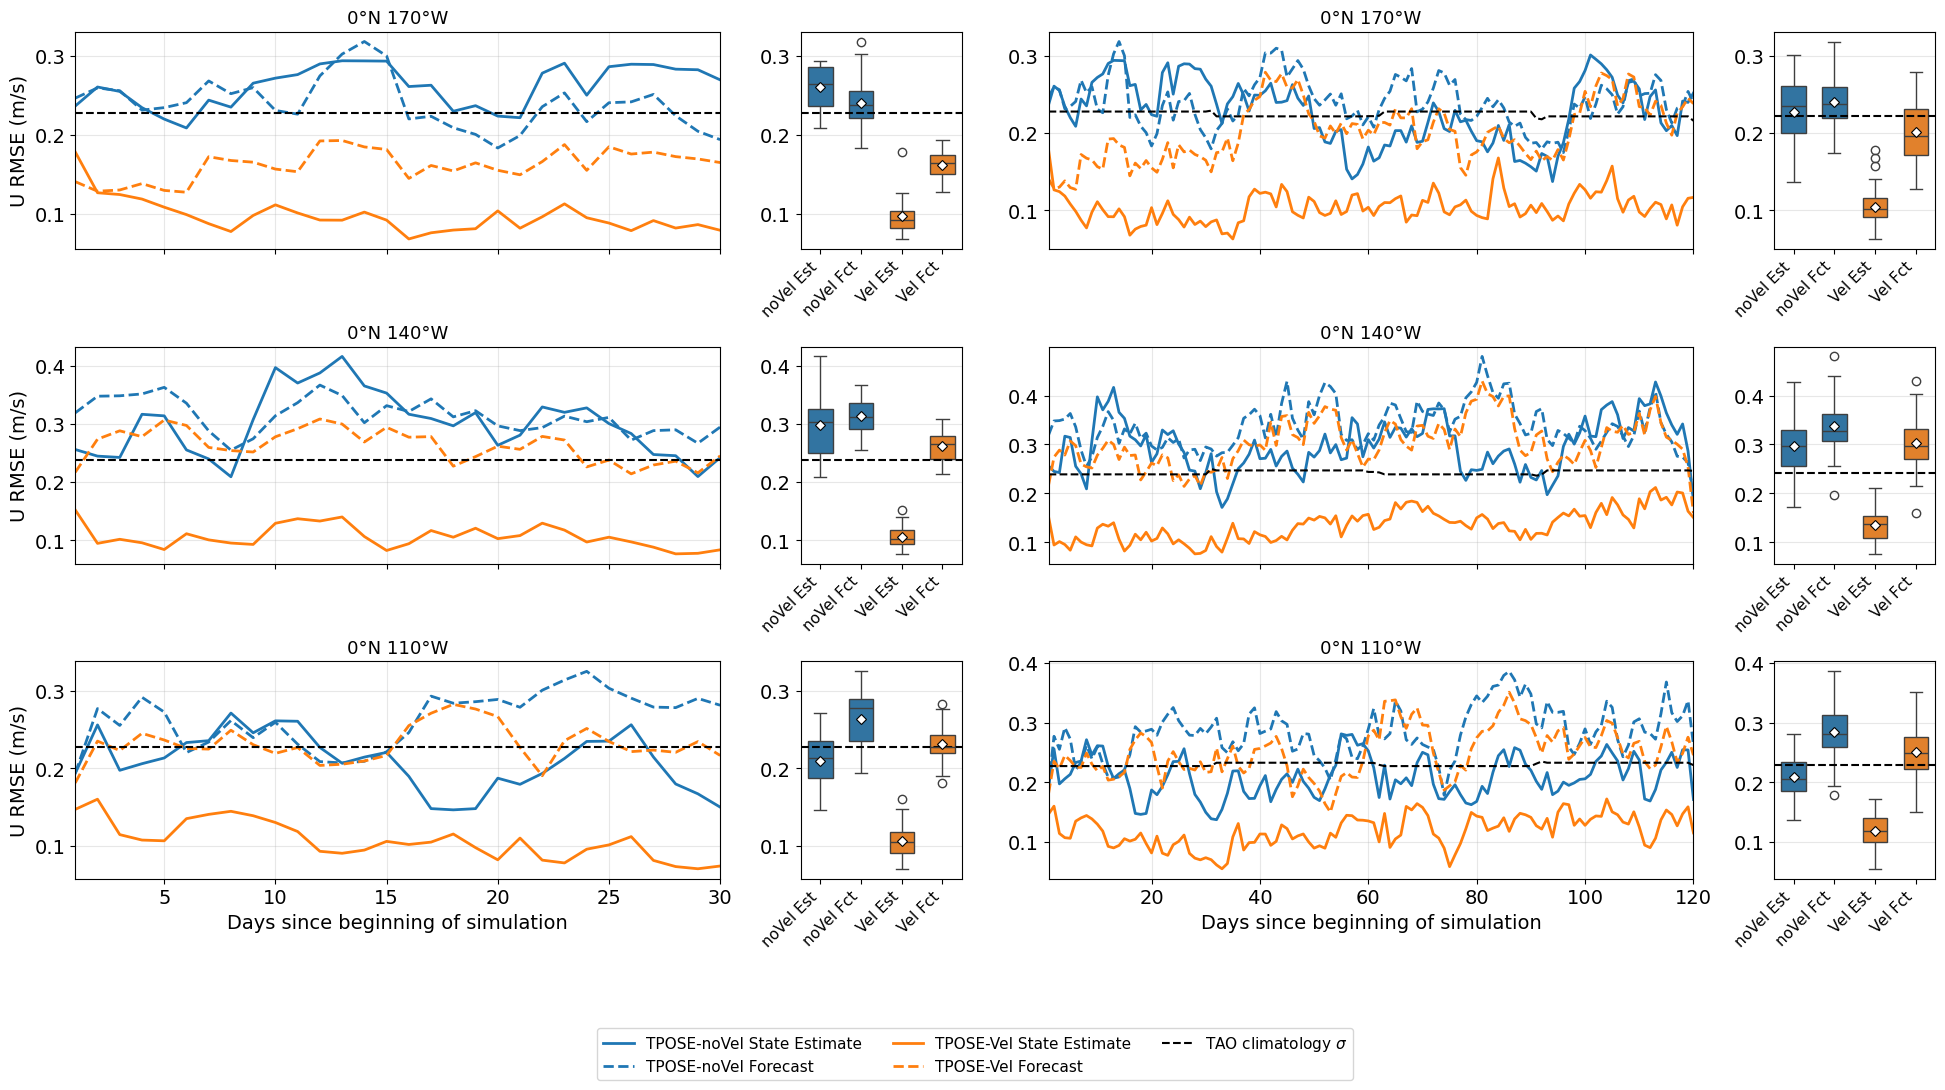

Saved /home/edavenport/analysis/vel-assim-manuscript/forecasts/results_figs/skill/multi_window/vel_u_rmse_per_loc_multi_window_sigma_clim_tpose_only.png


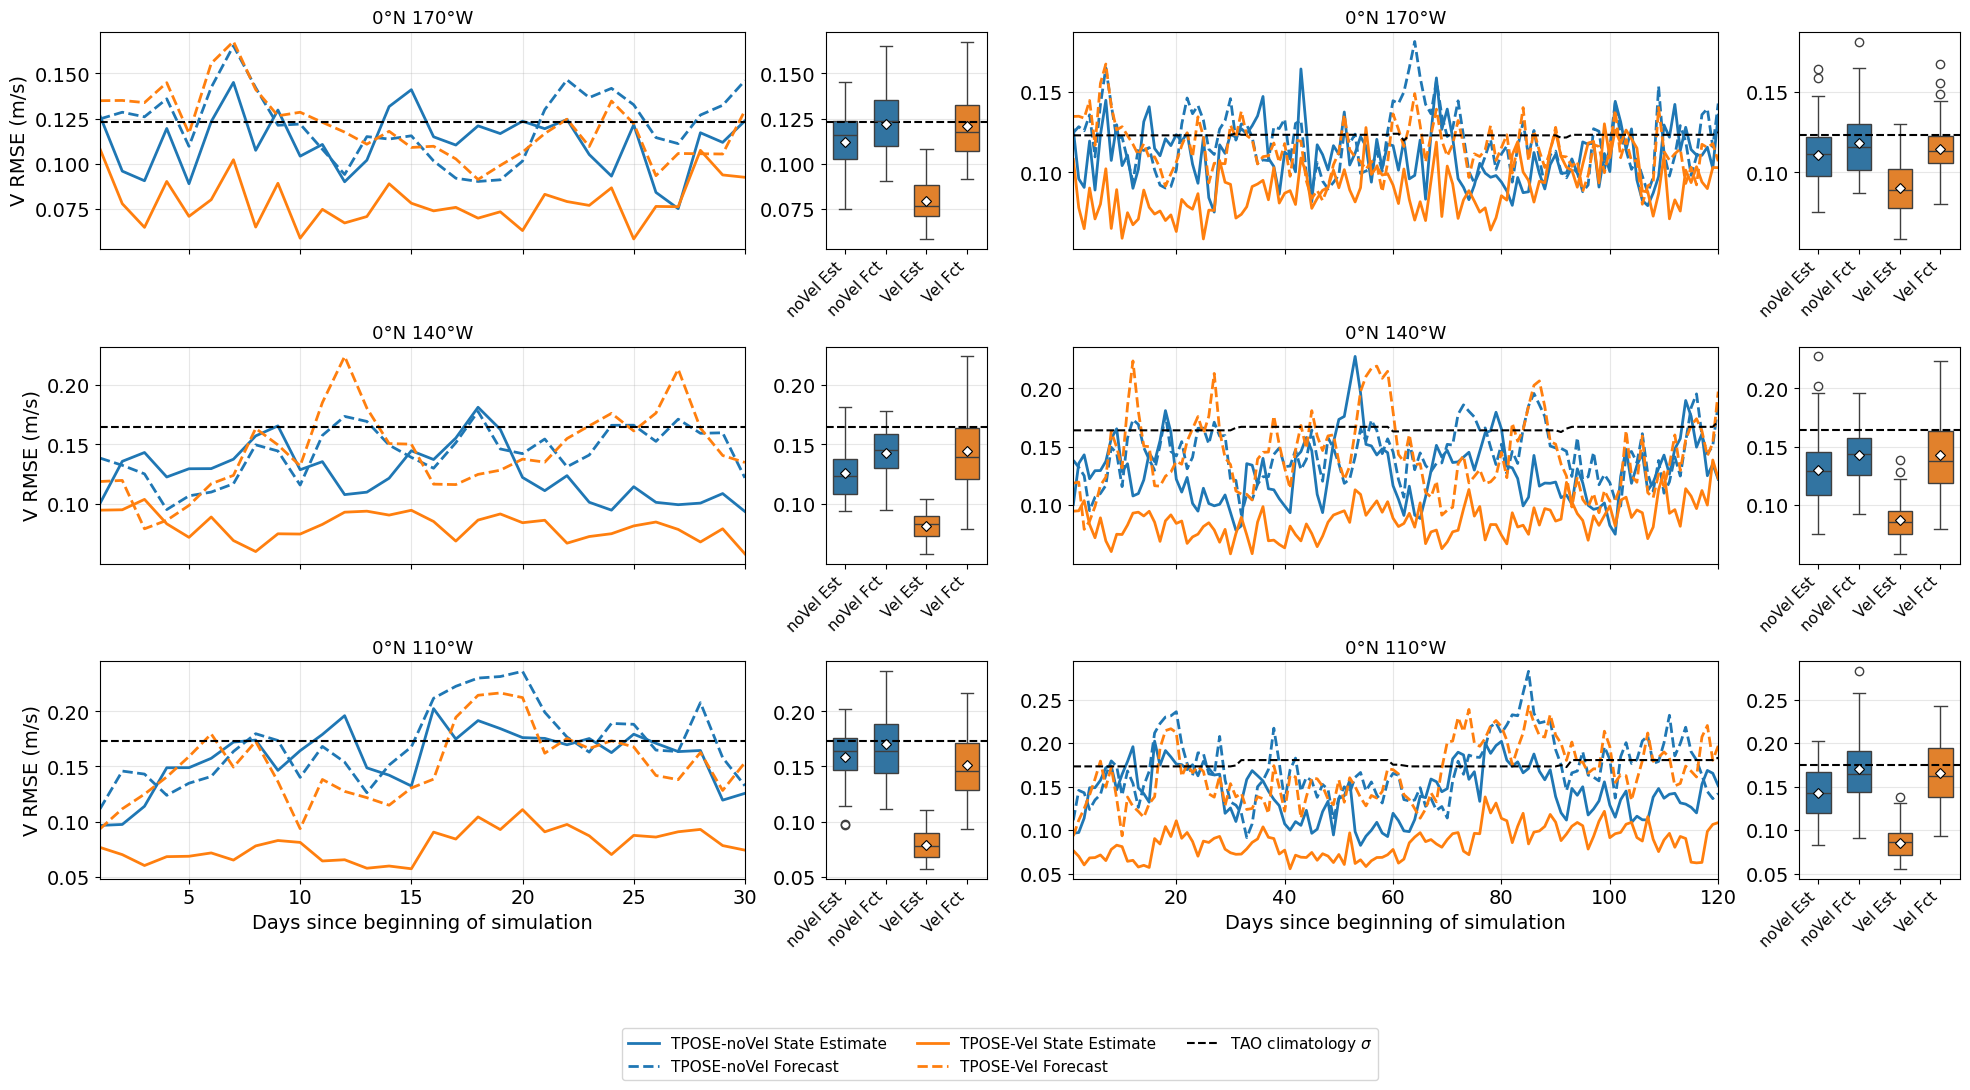

Saved /home/edavenport/analysis/vel-assim-manuscript/forecasts/results_figs/skill/multi_window/vel_v_rmse_per_loc_multi_window_sigma_clim_tpose_only.png


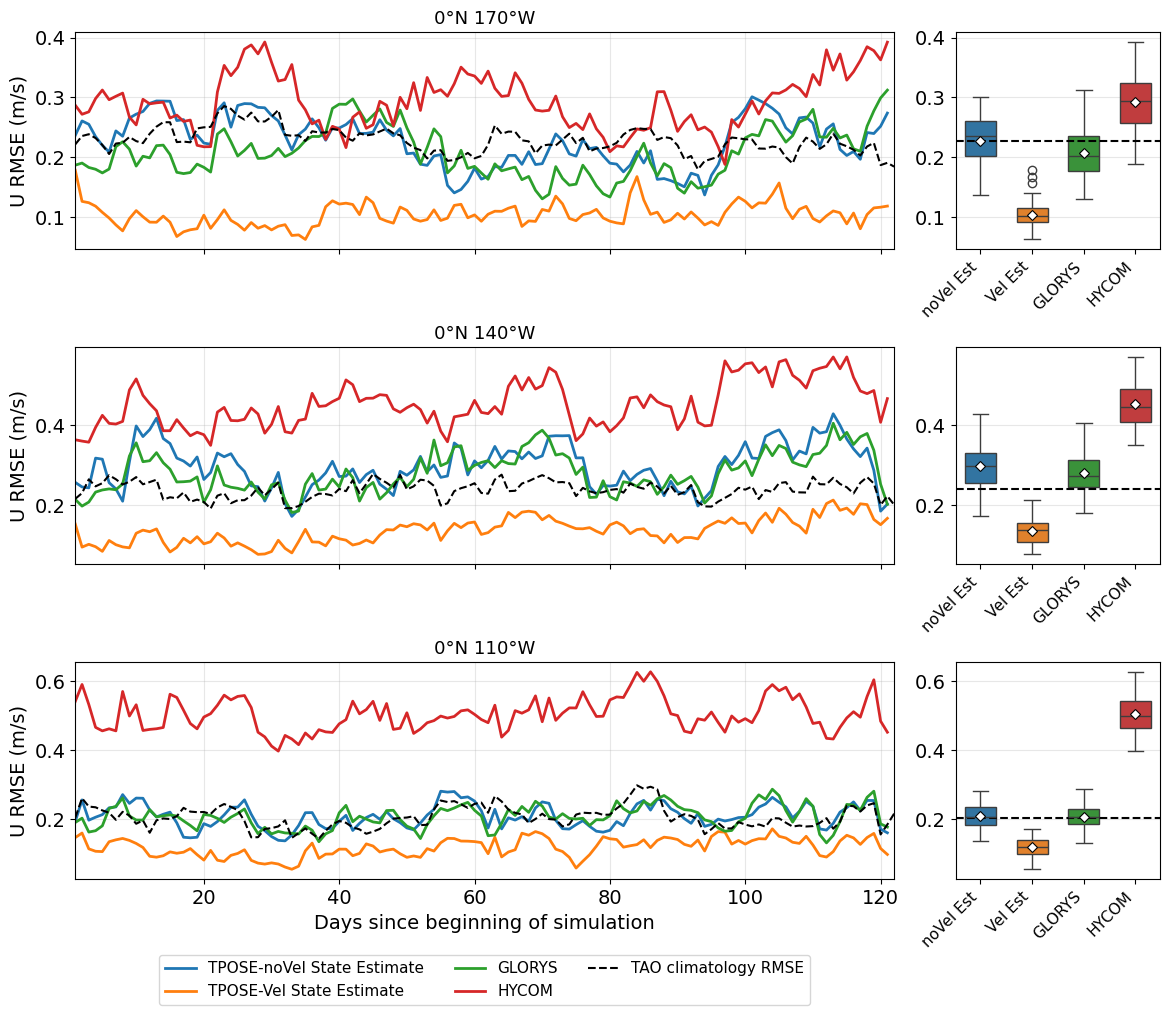

Saved /home/edavenport/analysis/vel-assim-manuscript/forecasts/results_figs/skill/multi_window/vel_u_rmse_per_loc_multi_window_rmse_clim.png


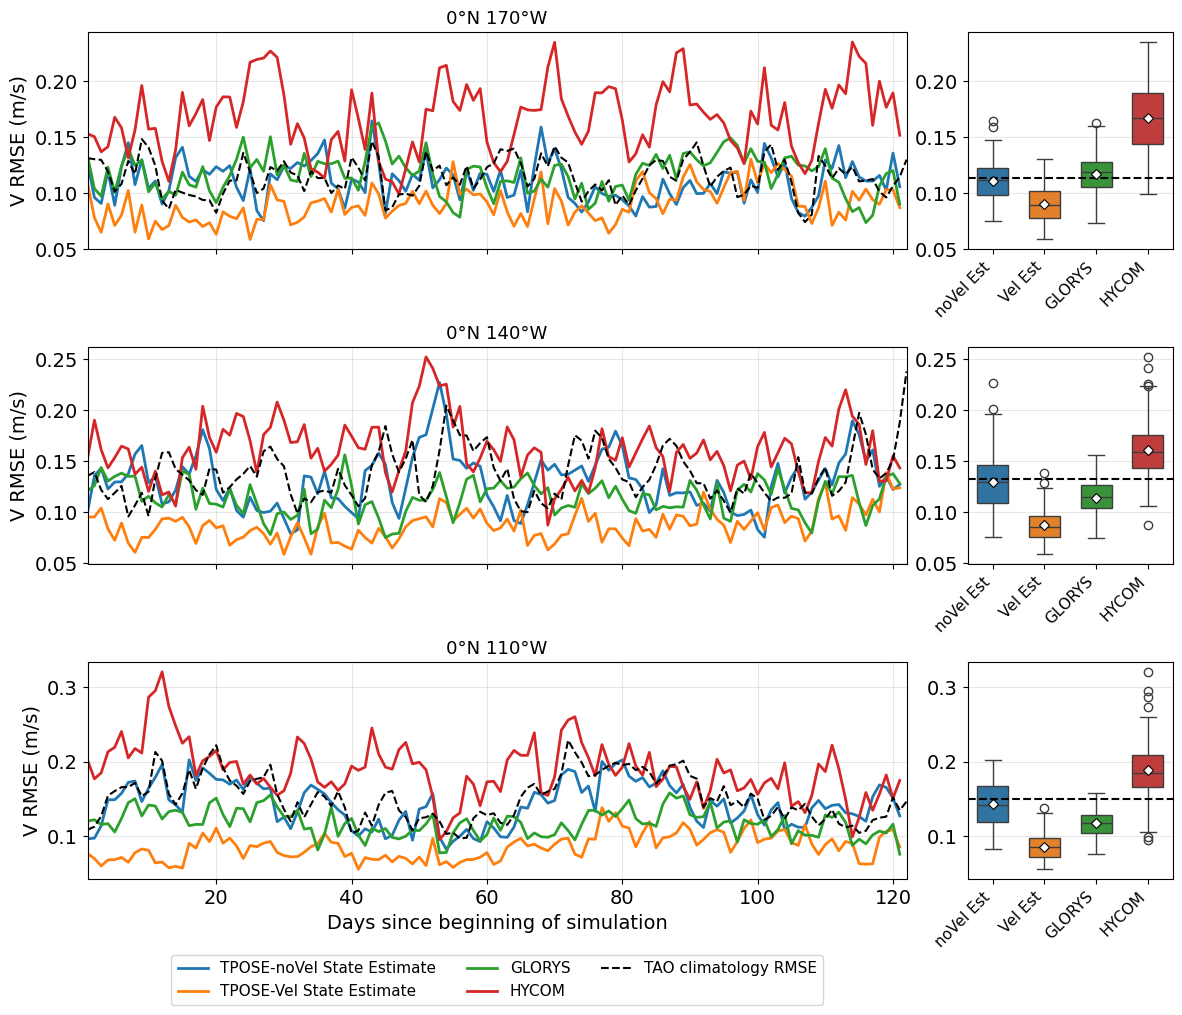

Saved /home/edavenport/analysis/vel-assim-manuscript/forecasts/results_figs/skill/multi_window/vel_v_rmse_per_loc_multi_window_rmse_clim.png


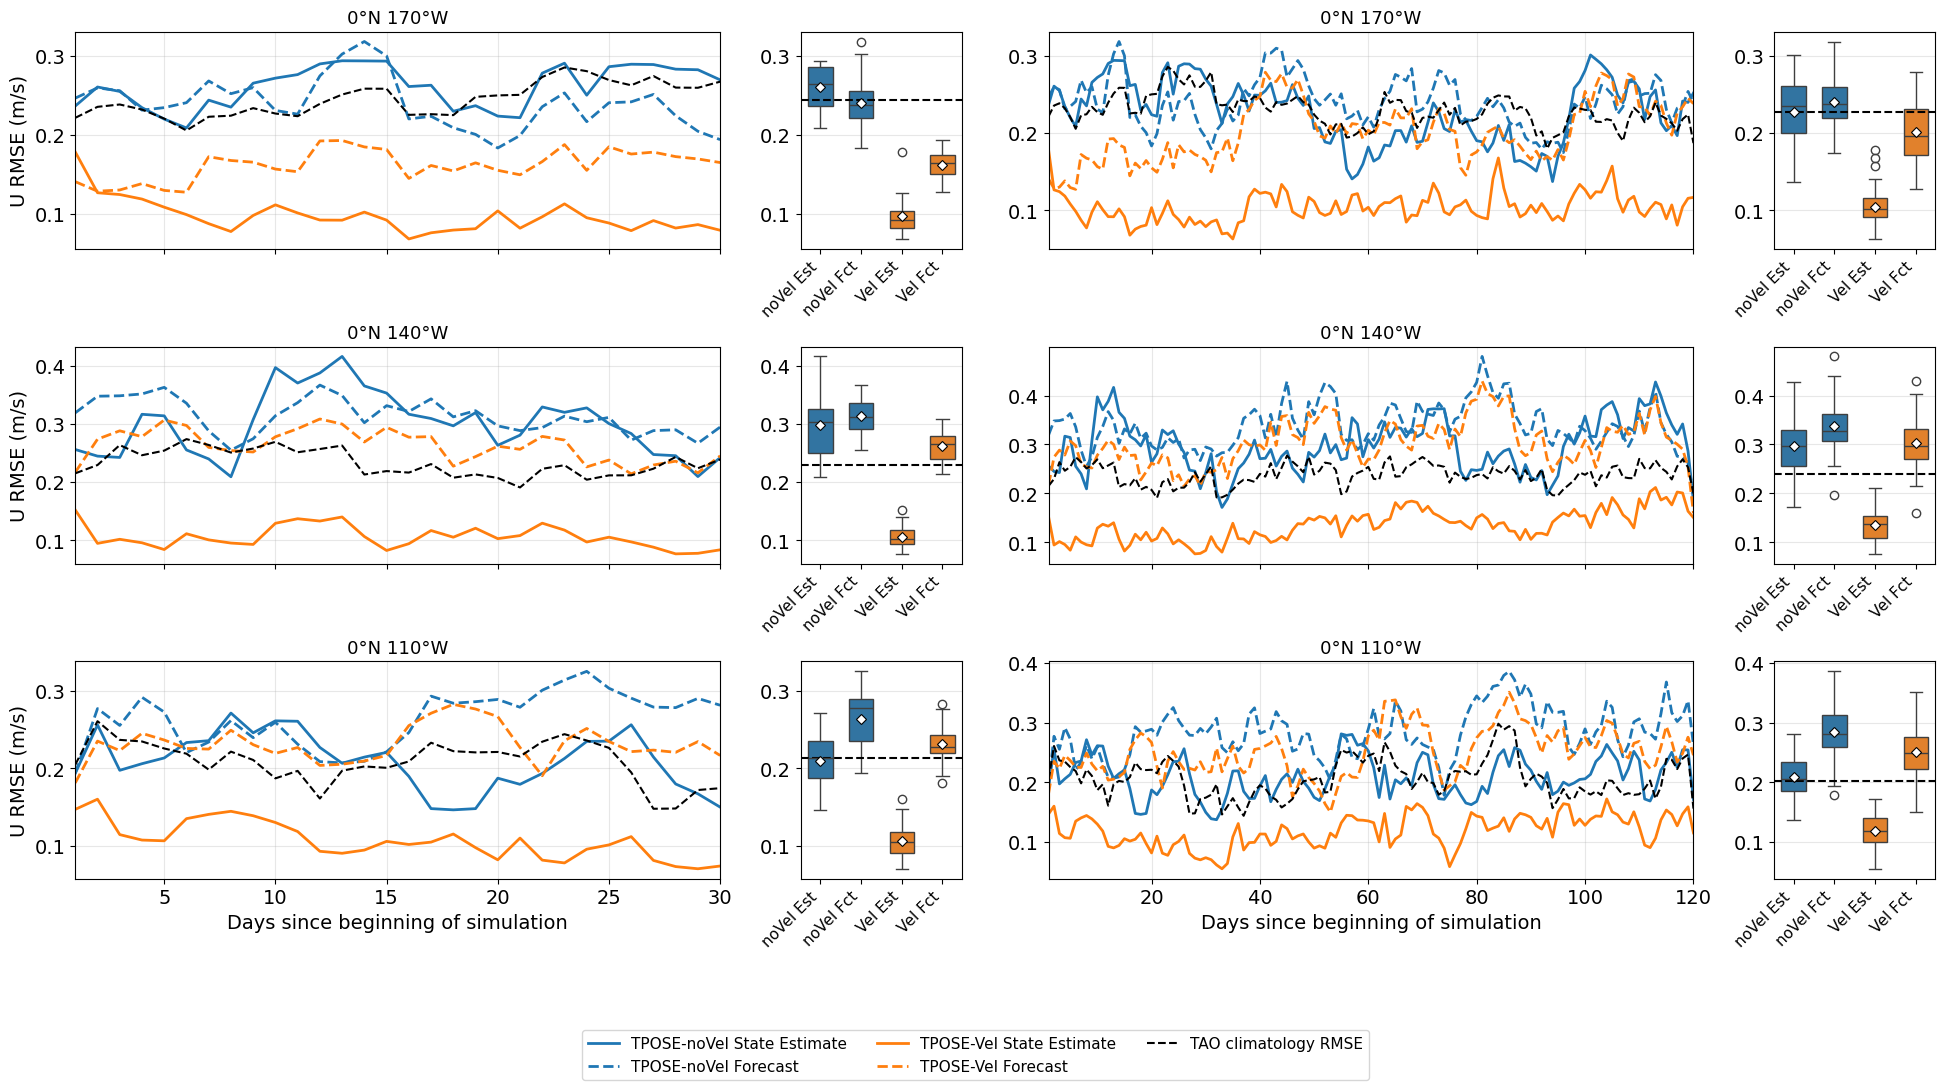

Saved /home/edavenport/analysis/vel-assim-manuscript/forecasts/results_figs/skill/multi_window/vel_u_rmse_per_loc_multi_window_rmse_clim_tpose_only.png


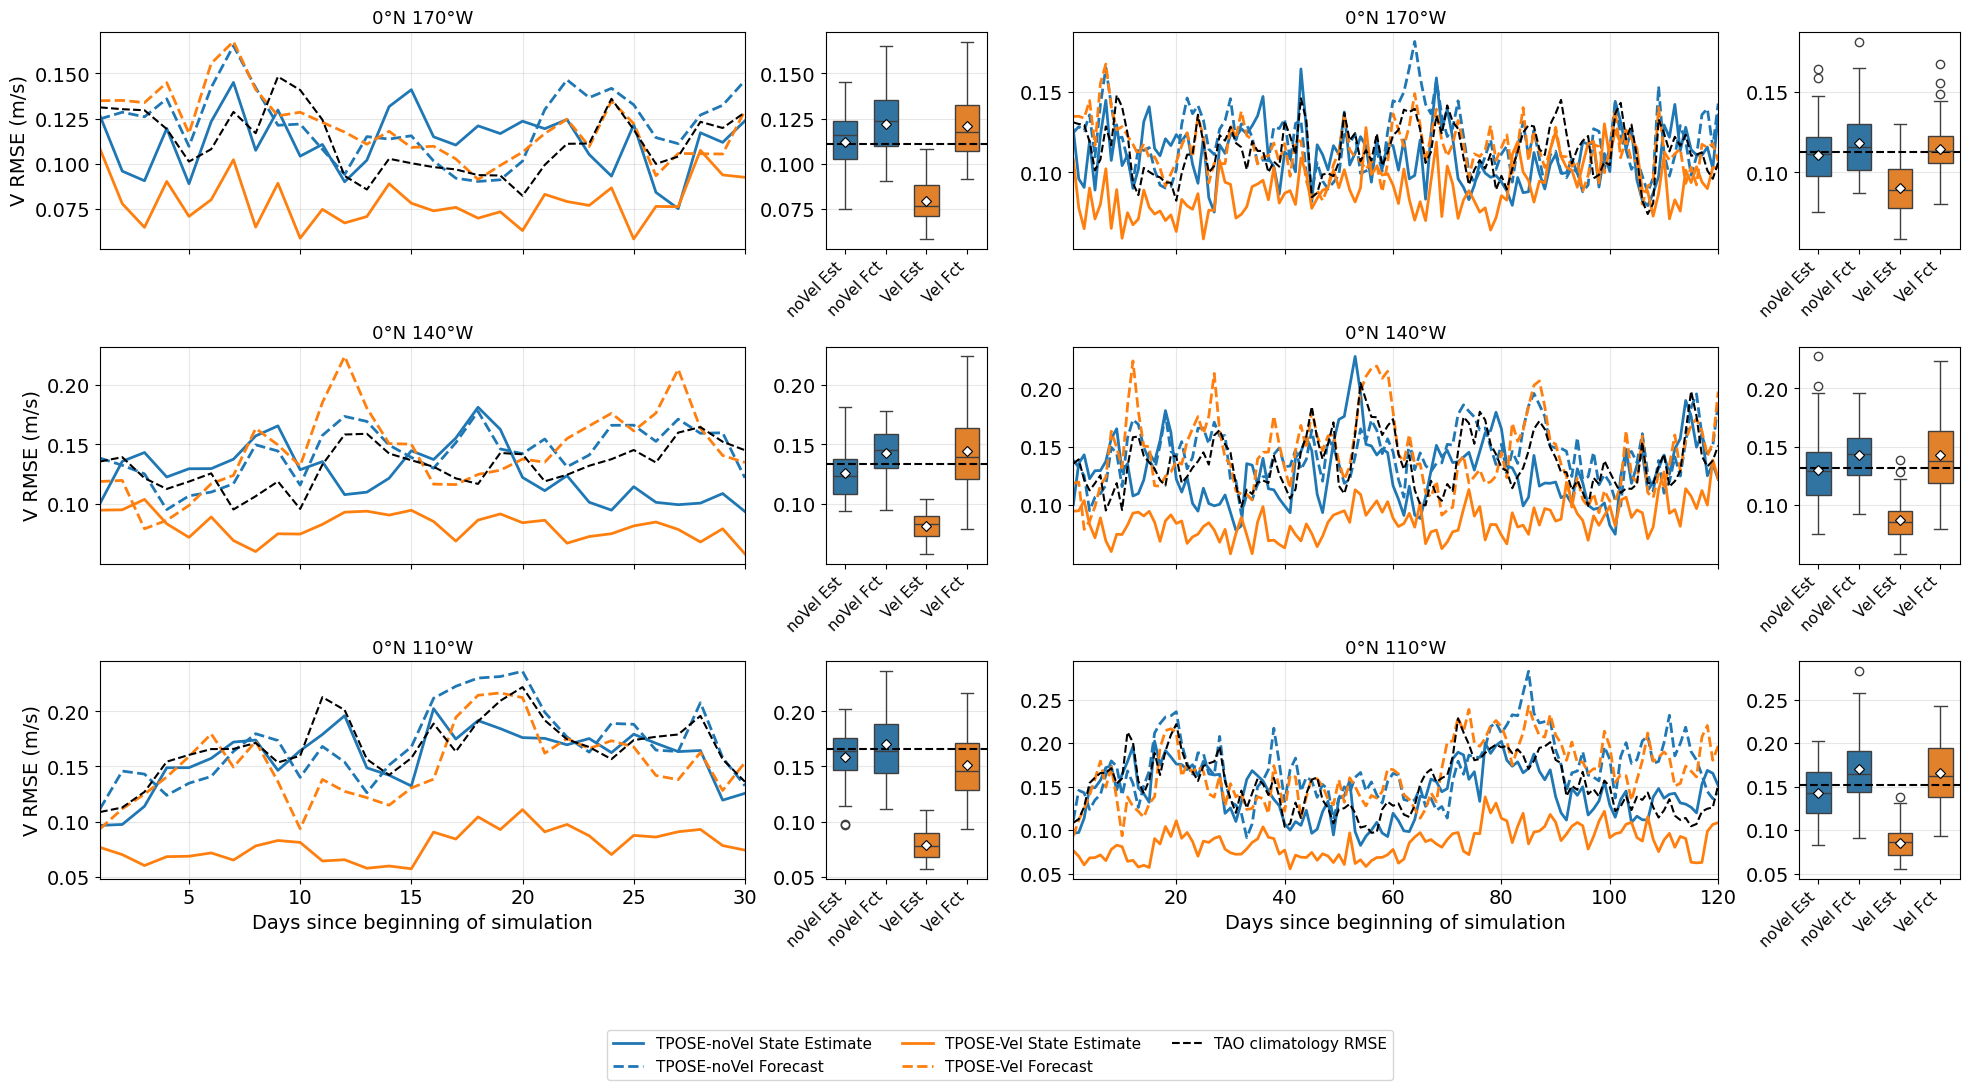

Saved /home/edavenport/analysis/vel-assim-manuscript/forecasts/results_figs/skill/multi_window/vel_v_rmse_per_loc_multi_window_rmse_clim_tpose_only.png


In [7]:
import seaborn as sns
import matplotlib.gridspec as gridspec

loc_titles = ['0°N 170°W', '0°N 140°W', '0°N 110°W']

# Each entry: (u_key, v_key, long_label, short_label, color, linestyle)
DATASET_SPECS = [
    ('noVel_est_u',   'noVel_est_v',   'TPOSE-noVel State Estimate', 'noVel Est',  'C0', '-'),
    ('noVel_fct_u',   'noVel_fct_v',   'TPOSE-noVel Forecast',       'noVel Fct',  'C0', '--'),
    ('noVel_pers_u',  'noVel_pers_v',  'TPOSE-noVel Persistence',    'noVel Pers', 'C0', ':'),
    ('vel_est_u',     'vel_est_v',     'TPOSE-Vel State Estimate',   'Vel Est',    'C1', '-'),
    ('vel_fct_u',     'vel_fct_v',     'TPOSE-Vel Forecast',         'Vel Fct',    'C1', '--'),
    ('vel_pers_u',    'vel_pers_v',    'TPOSE-Vel Persistence',      'Vel Pers',   'C1', ':'),
    ('glorys_u',      'glorys_v',      'GLORYS',                     'GLORYS',     'C2', '-'),
    ('hycom_u',       'hycom_v',       'HYCOM',                      'HYCOM',      'C3', '-'),
]

clim_registry = {
    'sigma_clim': (rmse_avg['sigma_clim_u'], rmse_avg['sigma_clim_v'], r'TAO climatology $\sigma$'),
    'rmse_clim':  (rmse_avg['rmse_clim_u'],  rmse_avg['rmse_clim_v'],  'TAO climatology RMSE'),
}
modes_to_run = list(clim_registry.keys()) if clim_mode == 'both' else [clim_mode]

tpose_fct_pers = {'noVel Fct', 'noVel Pers', 'Vel Fct', 'Vel Pers'}
# tpose_shorts   = {'noVel Est', 'noVel Fct', 'noVel Pers', 'Vel Est', 'Vel Fct', 'Vel Pers'}

# this version removes persistence
tpose_shorts   = {'noVel Est', 'noVel Fct', 'Vel Est', 'Vel Fct'}

# GLORYS/HYCOM figure: state estimates only (no TPOSE forecasts/persistence) + GLORYS + HYCOM
specs_all   = [s for s in DATASET_SPECS if s[3] not in tpose_fct_pers]
# TPOSE-only figure: all 6 TPOSE products
specs_tpose = [s for s in DATASET_SPECS if s[3] in tpose_shorts]


def make_figure(specs, clim_u, clim_v, uv_idx, component, file_suffix, clim_label):
    """2-column figure (full avg window): [time series | IQR], 3 rows (locations)."""
    clim    = clim_u if uv_idx == 0 else clim_v
    uk      = 0 if uv_idx == 0 else 1
    actives = [(s, rmse_avg[s[uk]]) for s in specs if rmse_avg[s[uk]] is not None]
    if not actives:
        print(f'No data for {component} {file_suffix}'); return

    short_names = [s[3] for s, _ in actives]
    palette     = [s[4] for s, _ in actives]
    long_labels = [s[2] for s, _ in actives]

    fig = plt.figure(figsize=(14, 11))
    gs  = gridspec.GridSpec(3, 2, width_ratios=[4, 1], hspace=0.45, wspace=0.12)

    for row, (loc_idx, loc_title) in enumerate(zip(range(n_loc), loc_titles)):
        ax_ts = fig.add_subplot(gs[row, 0])
        ax_bx = fig.add_subplot(gs[row, 1])

        ts_data = [arr[:, loc_idx] for _, arr in actives]

        for (spec, arr), label, ts in zip(actives, long_labels, ts_data):
            ax_ts.plot(days_avg, ts, color=spec[4], lw=2, ls=spec[5],
                       label=label if row == 0 else None)
        if clim is not None:
            ax_ts.plot(days_avg, clim[:, loc_idx], color='k', lw=1.5, ls='--',
                       label=clim_label if row == 0 else None)

        ax_ts.set_title(loc_title, fontsize=13)
        ax_ts.set_ylabel(f'{component} RMSE (m/s)')
        ax_ts.set_xlim(days_avg[0], days_avg[-1])
        ax_ts.grid(alpha=0.3)
        if row < 2:
            plt.setp(ax_ts.get_xticklabels(), visible=False)

        col_names = [f'ds{k}' for k in range(len(ts_data))]
        all_vals  = [d[~np.isnan(d)] for d in ts_data]
        box_df    = pd.DataFrame({n: pd.Series(v) for n, v in zip(col_names, all_vals)})
        pal_dict  = dict(zip(col_names, palette))
        sns.boxplot(data=box_df, ax=ax_bx, palette=pal_dict, width=0.6)
        for k, d in enumerate(ts_data):
            ax_bx.plot(k, np.nanmean(d), marker='D', ms=5,
                       color='white', mec='black', mew=0.8, zorder=5)
        if clim is not None:
            ax_bx.axhline(np.nanmedian(clim[:, loc_idx]), color='k', lw=1.5, ls='--')
        ax_bx.set_xticks(range(len(short_names)))
        ax_bx.set_xticklabels(short_names, fontsize=11, rotation=45, ha='right')
        ax_bx.set_ylabel('')
        ax_bx.grid(alpha=0.3, axis='y')

    fig.axes[4].set_xlabel('Days since beginning of simulation')

    handles, labels = fig.axes[0].get_legend_handles_labels()
    fig.axes[4].legend(handles, labels, loc='upper center',
                       bbox_to_anchor=(0.5, -0.35), ncol=3, borderaxespad=0, fontsize=11)

    fname = foldername + f'vel_{component.lower()}_rmse_per_loc_multi_window_{file_suffix}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}')


def make_figure_dual(specs, clim_u, clim_v, uv_idx, component, file_suffix, clim_label):
    """4-column TPOSE-only figure: [30d ts | 30d IQR | 120d ts | 120d IQR], 3 rows.
    IQR is computed only over the days shown in each panel."""
    clim_full = clim_u if uv_idx == 0 else clim_v
    uk        = 0 if uv_idx == 0 else 1
    actives   = [(s, rmse_avg[s[uk]]) for s in specs if rmse_avg[s[uk]] is not None]
    if not actives:
        print(f'No data for {component} {file_suffix}'); return

    short_names = [s[3] for s, _ in actives]
    palette     = [s[4] for s, _ in actives]
    long_labels = [s[2] for s, _ in actives]

    n_30  = 30
    n_120 = min(120, len(days_avg))
    sl_30  = slice(None, n_30)
    sl_120 = slice(None, n_120)
    days_30  = days_avg[sl_30]
    days_120 = days_avg[sl_120]
    clim_30  = clim_full[sl_30]  if clim_full is not None else None
    clim_120 = clim_full[sl_120] if clim_full is not None else None

    fig = plt.figure(figsize=(24, 11))
    outer = gridspec.GridSpec(1, 3, width_ratios=[5, 0.15, 5], figure=fig, wspace=0.05)
    gs_l = gridspec.GridSpecFromSubplotSpec(3, 2, subplot_spec=outer[0],
                                             width_ratios=[4, 1], hspace=0.45, wspace=0.20)
    gs_r = gridspec.GridSpecFromSubplotSpec(3, 2, subplot_spec=outer[2],
                                             width_ratios=[4, 1], hspace=0.45, wspace=0.20)

    for row, (loc_idx, loc_title) in enumerate(zip(range(n_loc), loc_titles)):
        ax_ts30  = fig.add_subplot(gs_l[row, 0])
        ax_bx30  = fig.add_subplot(gs_l[row, 1])
        ax_ts120 = fig.add_subplot(gs_r[row, 0])
        ax_bx120 = fig.add_subplot(gs_r[row, 1])

        ts_30  = [arr[sl_30,  loc_idx] for _, arr in actives]
        ts_120 = [arr[sl_120, loc_idx] for _, arr in actives]

        for (spec, arr), label, ts in zip(actives, long_labels, ts_30):
            ax_ts30.plot(days_30, ts, color=spec[4], lw=2, ls=spec[5],
                         label=label if row == 0 else None)
        if clim_30 is not None:
            ax_ts30.plot(days_30, clim_30[:, loc_idx], color='k', lw=1.5, ls='--',
                         label=clim_label if row == 0 else None)

        for (spec, arr), ts in zip(actives, ts_120):
            ax_ts120.plot(days_120, ts, color=spec[4], lw=2, ls=spec[5])
        if clim_120 is not None:
            ax_ts120.plot(days_120, clim_120[:, loc_idx], color='k', lw=1.5, ls='--')

        for ax_ts, plot_days in [(ax_ts30, days_30), (ax_ts120, days_120)]:
            ax_ts.set_xlim(plot_days[0], plot_days[-1])
            ax_ts.grid(alpha=0.3)
            if row < 2:
                plt.setp(ax_ts.get_xticklabels(), visible=False)

        ax_ts30.set_title(loc_title, fontsize=13)
        ax_ts120.set_title(loc_title, fontsize=13)
        ax_ts30.set_ylabel(f'{component} RMSE (m/s)')

        if row == 2:
            ax_ts30.set_xlabel('Days since beginning of simulation')
            ax_ts120.set_xlabel('Days since beginning of simulation')

        for ax_bx, ts_data, clim_arr in [
            (ax_bx30,  ts_30,  clim_30),
            (ax_bx120, ts_120, clim_120),
        ]:
            col_names = [f'ds{k}' for k in range(len(ts_data))]
            all_vals  = [d[~np.isnan(d)] for d in ts_data]
            box_df    = pd.DataFrame({n: pd.Series(v) for n, v in zip(col_names, all_vals)})
            pal_dict  = dict(zip(col_names, palette))
            sns.boxplot(data=box_df, ax=ax_bx, palette=pal_dict, width=0.6)
            for k, d in enumerate(ts_data):
                ax_bx.plot(k, np.nanmean(d), marker='D', ms=5,
                           color='white', mec='black', mew=0.8, zorder=5)
            if clim_arr is not None:
                ax_bx.axhline(np.nanmedian(clim_arr[:, loc_idx]), color='k', lw=1.5, ls='--')
            ax_bx.set_xticks(range(len(short_names)))
            ax_bx.set_xticklabels(short_names, fontsize=11, rotation=45, ha='right')
            ax_bx.set_ylabel('')
            ax_bx.grid(alpha=0.3, axis='y')

    handles, labels = fig.axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=3,
               bbox_to_anchor=(0.5, -0.08), fontsize=11)

    fname = foldername + f'vel_{component.lower()}_rmse_per_loc_multi_window_{file_suffix}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}')


for mode in modes_to_run:
    clim_u, clim_v, clim_label = clim_registry[mode]
    make_figure(specs_all, clim_u, clim_v, 0, 'U', mode, clim_label)
    make_figure(specs_all, clim_u, clim_v, 1, 'V', mode, clim_label)
    make_figure_dual(specs_tpose, clim_u, clim_v, 0, 'U', mode + '_tpose_only', clim_label)
    make_figure_dual(specs_tpose, clim_u, clim_v, 1, 'V', mode + '_tpose_only', clim_label)